In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, measure

In [2]:
image_pixels = io.imread("images/astronaut.jpg")
image_pixels.shape

(512, 512, 3)

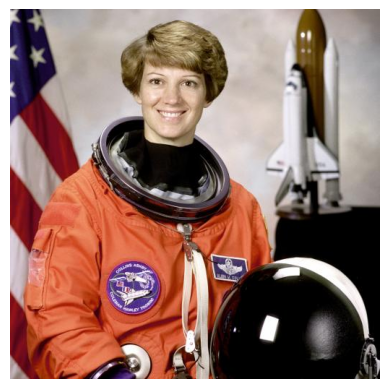

In [3]:
plt.imshow(image_pixels, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
if image_pixels.shape[-1] == 4:
    image_pixels = image_pixels[..., :3]

In [5]:
gray_img = color.rgb2gray(image_pixels)
gray_img.shape

(512, 512)

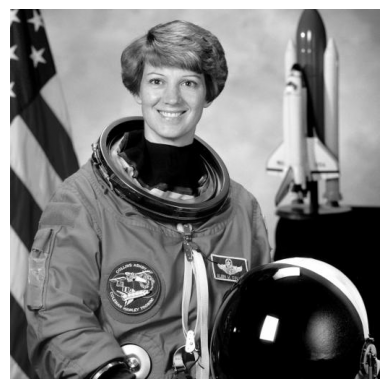

In [6]:
plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()

In [7]:
edge_sobel = filters.sobel(gray_img)
edge_sobel.shape

(512, 512)

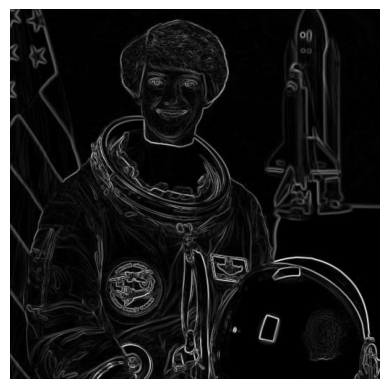

In [8]:
from skimage.util import img_as_ubyte

io.imsave("images/edge_sobel.png", img_as_ubyte(edge_sobel))

plt.imshow(edge_sobel, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
threshold = 0.2
edges = edge_sobel > threshold
edges.shape, edges.sum()

((512, 512), np.int64(11705))

In [10]:
edge_pixel_indices = np.nonzero(edges)
edge_pixel_indices

(array([  0,   1,   1, ..., 511, 511, 511], shape=(11705,)),
 array([  1,   1,   2, ..., 478, 505, 508], shape=(11705,)))

In [11]:
edges[edge_pixel_indices[0][0], edge_pixel_indices[1][0]]

np.True_

In [12]:
edge_points = np.column_stack(np.nonzero(edges))
edge_points[:3]

array([[0, 1],
       [1, 1],
       [1, 2]])

In [13]:
contours = measure.find_contours(edges, level=0.5)
contours

[array([[0. , 1.5],
        [0.5, 2. ],
        [0.5, 3. ],
        [0.5, 4. ],
        [0.5, 5. ],
        [1. , 5.5],
        [1.5, 5. ],
        [2. , 4.5],
        [2.5, 4. ],
        [2.5, 3. ],
        [2.5, 2. ],
        [2. , 1.5],
        [1.5, 1. ],
        [1. , 0.5],
        [0. , 0.5]]),
 array([[15.5, 13. ],
        [15. , 12.5],
        [14.5, 12. ],
        [14.5, 11. ],
        [14. , 10.5],
        [13.5, 10. ],
        [13. ,  9.5],
        [12.5,  9. ],
        [12. ,  8.5],
        [11. ,  8.5],
        [10.5,  8. ],
        [10. ,  7.5],
        [ 9.5,  7. ],
        [ 9. ,  6.5],
        [ 8. ,  6.5],
        [ 7. ,  6.5],
        [ 6. ,  6.5],
        [ 5.5,  7. ],
        [ 5. ,  7.5],
        [ 4.5,  8. ],
        [ 4. ,  8.5],
        [ 3. ,  8.5],
        [ 2.5,  9. ],
        [ 2. ,  9.5],
        [ 1.5, 10. ],
        [ 1. , 10.5],
        [ 0.5, 11. ],
        [ 1. , 11.5],
        [ 2. , 11.5],
        [ 3. , 11.5],
        [ 3.5, 11. ],
        [ 4. , 1

In [14]:
test_cont = contours[0]
test_cont.shape

(15, 2)

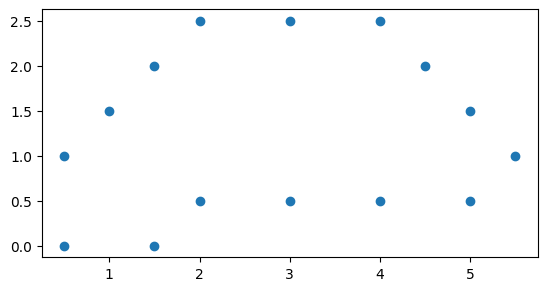

In [15]:
plt.plot(test_cont[:, 1], test_cont[:, 0], 'o')
plt.axis('image')
plt.show()

In [16]:
largest_countour_idx = 0
largest_countour_cnt = -1
for i, contour in enumerate(contours):
    n_points = contour.shape[0]
    if n_points < 20:
        continue

    if n_points > largest_countour_cnt:
        largest_countour_cnt = n_points
        largest_countour_idx = i
        print(f"New largest contour: {n_points}")

        y_vals = contour[:, 0]
        x_vals = contour[:, 1]

x_vals.shape, y_vals.shape

New largest contour: 51
New largest contour: 229
New largest contour: 291
New largest contour: 343
New largest contour: 627


((627,), (627,))

In [17]:
t = np.arange(len(y_vals))
n = len(t)
n, t

(627,
 array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 17

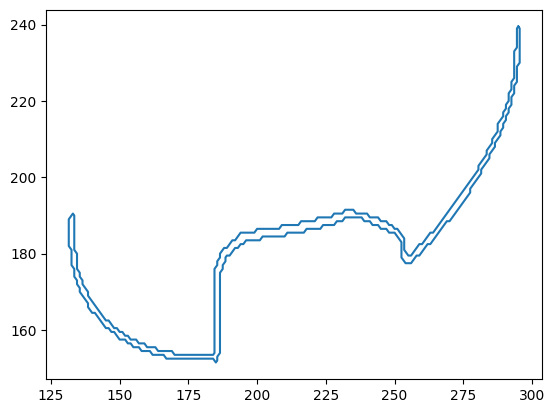

In [18]:
plt.plot(x_vals, y_vals)
plt.show()

In [19]:
from scipy.interpolate import CubicSpline

In [20]:
sx = CubicSpline(t, x_vals, bc_type="natural")
sy = CubicSpline(t, y_vals, bc_type="natural")

In [21]:
t_for_plot = np.linspace(0, n-1, 5000)
x_poly = sx(t_for_plot)
y_poly = sy(t_for_plot)

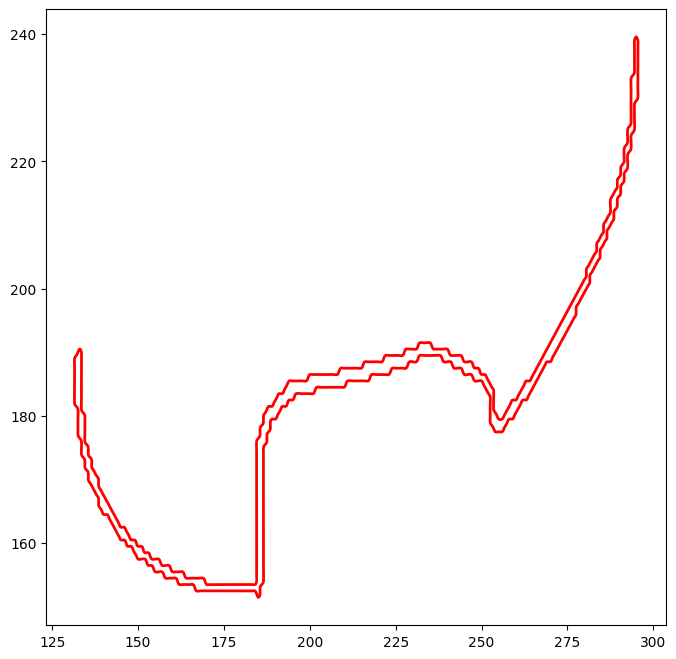

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_poly, y_poly, color="red", linewidth=2)